# IntelliPulse V1 — Baseline Churn Prediction

---

## 1 · Project Introduction

**IntelliPulse** is an AI/ML observability platform designed to monitor data quality, data drift, model performance degradation, RAG/LLM reliability, AI system health, and to provide root-cause explanations and recommendations.

### What V1 accomplishes

Before building any monitoring infrastructure, we need a **working baseline model** and a clear understanding of our dataset. V1 focuses on:

1. Understanding the raw dataset through thorough exploratory data analysis (EDA).
2. Cleaning and preprocessing the data with a reproducible pipeline.
3. Training a **baseline churn prediction model** (Logistic Regression).
4. Evaluating the model with appropriate classification metrics.
5. Saving the trained model and preprocessing pipeline as artifacts.
6. Documenting the experiment so it can be reproduced and built upon.

### Business Problem

> *"Given information about a telecom customer, predict the probability that the customer will churn."*

This is a **binary classification** problem:
- **Positive class (1):** The customer *will* churn.
- **Negative class (0):** The customer *will not* churn.

### Dataset

We use the **IBM Telco Customer Churn** dataset (`WA_Fn-UseC_-Telco-Customer-Churn.csv`), which contains demographic, account, service, and billing information for ~7,000 telecom customers alongside a binary churn label.

### Why binary classification?

The target variable (`Churn`) takes exactly two values — *Yes* and *No* — making this a textbook binary classification task. We care not just about the predicted class, but also about the **predicted probability** (how confident the model is), because downstream business decisions (e.g., retention campaigns) depend on risk scores, not only hard labels.

> **Note:** The model learns *predictive* relationships between customer features and churn. We do **not** claim that the model discovers causal relationships.

---

## 2 · Imports and Configuration

We use standard, well-supported libraries:

| Library | Purpose |
|---------|---------|
| `pandas` | Tabular data manipulation |
| `numpy` | Numerical operations |
| `matplotlib` / `seaborn` | Visualization |
| `scikit-learn` | Preprocessing, modeling, evaluation |
| `joblib` | Model serialization |
| `json` / `os` / `pathlib` | Filesystem utilities |

A fixed `RANDOM_STATE` ensures reproducibility — anyone re-running this notebook will get the same train/test split and model coefficients.

In [1]:
# ── Standard library ──────────────────────────────────────────────────
import os
import json
from pathlib import Path

# ── Data & numerics ──────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── scikit-learn: preprocessing ──────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# ── scikit-learn: model ──────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

# ── scikit-learn: evaluation ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

# ── Persistence ──────────────────────────────────────────────────────
import joblib

# ── Configuration ────────────────────────────────────────────────────
RANDOM_STATE = 42

# Plotting defaults
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Project paths (relative to repository root)
PROJECT_ROOT = Path.cwd().parent  # notebook lives in notebooks/
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"

print(f"Project root : {PROJECT_ROOT}")
print(f"Raw data path: {RAW_DATA_PATH}")
print(f"Random state : {RANDOM_STATE}")

Project root : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse
Raw data path: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
Random state : 42


---

## 3 · Load Raw Data

We load the CSV and immediately verify it exists. The raw dataframe is stored as `df_raw` and is **never modified in place**. All subsequent work is performed on a working copy (`df`).

In [2]:
# Verify the dataset exists
assert RAW_DATA_PATH.exists(), (
    f"Dataset not found at {RAW_DATA_PATH}. "
    "Please place WA_Fn-UseC_-Telco-Customer-Churn.csv in data/raw/"
)

df_raw = pd.read_csv(RAW_DATA_PATH)

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumn names:\n{list(df_raw.columns)}\n")
df_raw.head()

Shape: 7,043 rows × 21 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Create a working copy — df_raw remains untouched
df = df_raw.copy()

---

## 4 · Data Understanding

### Conceptual grouping of features

We organise the 21 columns into meaningful groups:

| Group | Columns |
|-------|---------|
| **Identifier** | `customerID` |
| **Demographics** | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| **Account** | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod` |
| **Services** | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Billing** | `MonthlyCharges`, `TotalCharges` |
| **Target** | `Churn` |

> **Why not drop demographics right away?**
> Features like `gender` or `SeniorCitizen` may or may not have predictive value. Removing them *before* analysis would be a premature decision. We investigate first and decide later.

### Why exclude `customerID` from modeling?

`customerID` is a **unique row identifier** — it carries no information about customer behaviour. Including it would let the model memorise individual IDs, which is pure noise and would hurt generalisation.

In [6]:
# Identify column categories
ID_COL = "customerID"
TARGET_COL = "Churn"

# We'll determine numerical vs. categorical after fixing dtypes in Section 5.
# For now, let's check unique-value counts to get a quick overview.
unique_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "sample_values": [df[c].dropna().unique()[:5].tolist() for c in df.columns],
})
unique_summary

,dtype,n_unique,sample_values
customerID,str,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
gender,str,2,"[Female, Male]"
SeniorCitizen,int64,2,"[0, 1]"
Partner,str,2,"[Yes, No]"
Dependents,str,2,"[No, Yes]"
tenure,int64,73,"[1, 34, 2, 45, 8]"
PhoneService,str,2,"[No, Yes]"
MultipleLines,str,3,"[No phone service, No, Yes]"
InternetService,str,3,"[DSL, Fiber optic, No]"
OnlineSecurity,str,3,"[No, Yes, No internet service]"


---

## 5 · Data Quality Audit

A systematic quality audit before any modeling prevents subtle bugs downstream.

We check:
1. Missing / null values
2. Duplicated rows and duplicate customer IDs
3. Unexpected data types (especially `TotalCharges`)
4. Whitespace or inconsistent categorical values
5. Suspicious / impossible numerical values

### 5.1 Missing and null values

In [7]:
# Standard null check
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)

null_summary = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
null_summary[null_summary["null_count"] > 0]  # show only columns with nulls

,null_count,null_pct


In [8]:
# However, this dataset is known to encode missing values as blank strings
# rather than NaN. Let's also check for empty strings and whitespace-only values.

blank_counts = {}
for col in df.select_dtypes(include="object").columns:
    n_blank = (df[col].str.strip() == "").sum()
    if n_blank > 0:
        blank_counts[col] = n_blank

if blank_counts:
    print("Columns with blank / whitespace-only values:")
    for col, cnt in blank_counts.items():
        print(f"  {col}: {cnt} rows")
else:
    print("No blank strings found in object columns.")

Columns with blank / whitespace-only values:
  TotalCharges: 11 rows


/var/folders/0r/0rw063g545sgm09f_kcfv1bm0000gn/T/ipykernel_50809/4110587568.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


### 5.2  The `TotalCharges` problem

`TotalCharges` is read as `object` (string) instead of `float64`. This is because some rows contain blank strings `" "` instead of a numeric value.

**Root cause:** Customers with `tenure == 0` (brand-new customers who have not yet been billed) have no total charges recorded — the field is left blank rather than set to `0` or `NaN`.

**How we handle it:**
1. Convert `TotalCharges` to numeric, coercing non-numeric values to `NaN`.
2. Quantify how many rows are affected.
3. Decide on an imputation strategy (we will fill with `0.0` since these are new customers with no billing history yet).

> We do **not** silently drop these rows — they represent valid customers.

In [9]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

n_missing_tc = df["TotalCharges"].isnull().sum()
pct_missing_tc = n_missing_tc / len(df) * 100

print(f"TotalCharges: {n_missing_tc} missing values ({pct_missing_tc:.2f}% of rows)")

# Inspect the affected rows
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

TotalCharges: 11 missing values (0.16% of rows)


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [10]:
# Fill missing TotalCharges with 0.0 (new customers with no billing history)
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

# Verify
assert df["TotalCharges"].isnull().sum() == 0, "TotalCharges still has nulls"
print("TotalCharges cleaned — no remaining nulls.")

TotalCharges cleaned — no remaining nulls.


### 5.3 Duplicate rows and duplicate IDs

In [11]:
n_dup_rows = df.duplicated().sum()
n_dup_ids = df[ID_COL].duplicated().sum()

print(f"Duplicate rows      : {n_dup_rows}")
print(f"Duplicate customerIDs: {n_dup_ids}")

Duplicate rows      : 0
Duplicate customerIDs: 0


### 5.4 Categorical consistency check

In [12]:
# Print unique values for each categorical column to spot inconsistencies
cat_cols_raw = df.select_dtypes(include="object").columns.drop([ID_COL, TARGET_COL])

for col in cat_cols_raw:
    vals = sorted(df[col].unique())
    print(f"{col:20s} ({len(vals)} unique): {vals}")

gender               (2 unique): ['Female', 'Male']
Partner              (2 unique): ['No', 'Yes']
Dependents           (2 unique): ['No', 'Yes']
PhoneService         (2 unique): ['No', 'Yes']
MultipleLines        (3 unique): ['No', 'No phone service', 'Yes']
InternetService      (3 unique): ['DSL', 'Fiber optic', 'No']
OnlineSecurity       (3 unique): ['No', 'No internet service', 'Yes']
OnlineBackup         (3 unique): ['No', 'No internet service', 'Yes']
DeviceProtection     (3 unique): ['No', 'No internet service', 'Yes']
TechSupport          (3 unique): ['No', 'No internet service', 'Yes']
StreamingTV          (3 unique): ['No', 'No internet service', 'Yes']
StreamingMovies      (3 unique): ['No', 'No internet service', 'Yes']
Contract             (3 unique): ['Month-to-month', 'One year', 'Two year']
PaperlessBilling     (2 unique): ['No', 'Yes']
PaymentMethod        (4 unique): ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


/var/folders/0r/0rw063g545sgm09f_kcfv1bm0000gn/T/ipykernel_50809/2194947884.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_raw = df.select_dtypes(include="object").columns.drop([ID_COL, TARGET_COL])


### 5.5 SeniorCitizen encoding

`SeniorCitizen` is already encoded as `0/1` integers, but it is semantically a binary categorical variable. We note this for later — the pipeline will treat it as numerical (since it is already numeric), which is fine for Logistic Regression.

In [13]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

### 5.6 Numerical plausibility

In [14]:
# Quick sanity check on numerical ranges
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


### 5.7 Define final column lists

Now that `TotalCharges` is numeric, we can define our column lists cleanly.

In [15]:
NUMERICAL_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

CATEGORICAL_FEATURES = [
    "gender", "Partner", "Dependents",
    "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

# Verify we haven't missed anything
all_accounted = set([ID_COL, TARGET_COL] + NUMERICAL_FEATURES + CATEGORICAL_FEATURES)
all_columns = set(df.columns)
assert all_accounted == all_columns, f"Unaccounted columns: {all_columns - all_accounted}"

print(f"Numerical features  : {len(NUMERICAL_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Total features      : {len(NUMERICAL_FEATURES) + len(CATEGORICAL_FEATURES)}")

Numerical features  : 4
Categorical features: 15
Total features      : 19


---

## 6 · Target Analysis

Understanding the distribution of the target variable is essential *before* building a model. If one class dominates, **accuracy alone** can be misleading — a model that always predicts "No churn" would still achieve high accuracy but would be useless for identifying at-risk customers.

### Why accuracy is misleading for imbalanced targets

If 73% of customers do not churn, a model that *always* predicts "No" achieves 73% accuracy — without learning anything. Metrics like **Precision**, **Recall**, **F1**, and **ROC-AUC** give a more balanced picture.

In [16]:
target_counts = df[TARGET_COL].value_counts()
target_pcts = df[TARGET_COL].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({"count": target_counts, "pct": target_pcts})
target_summary

,count,pct
Churn,,
No,5174,73.46
Yes,1869,26.54


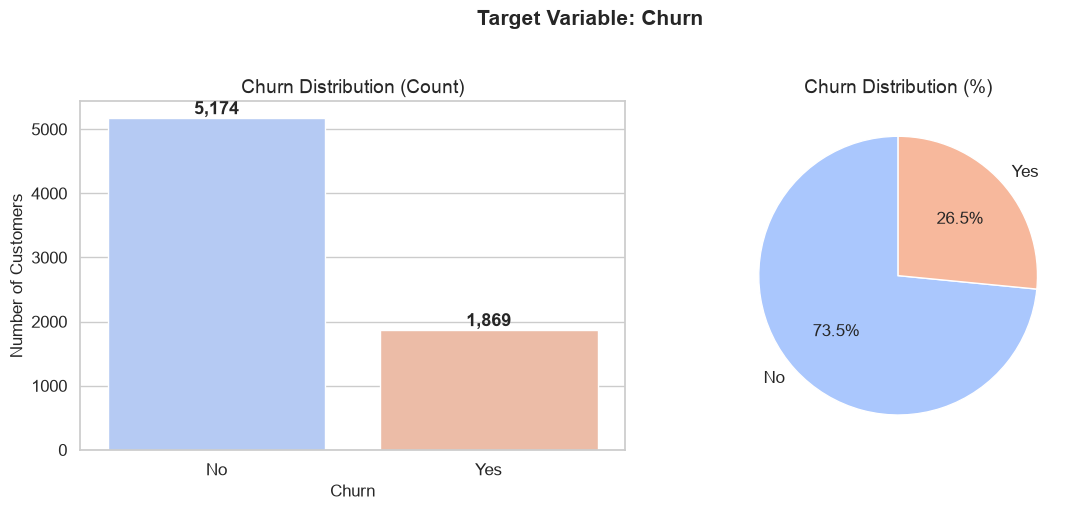

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df, x=TARGET_COL, hue=TARGET_COL, ax=axes[0], palette="coolwarm", legend=False)
axes[0].set_title("Churn Distribution (Count)")
axes[0].set_ylabel("Number of Customers")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontweight="bold")

# Percentage pie
colors = sns.color_palette("coolwarm", 2)
axes[1].pie(target_counts, labels=target_counts.index,
            autopct="%1.1f%%", startangle=90, colors=colors,
            textprops={"fontsize": 12})
axes[1].set_title("Churn Distribution (%)")

plt.suptitle("Target Variable: Churn", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Observation

The target is **moderately imbalanced** — roughly 73% No vs. 27% Yes. This is not extreme, but it is enough that accuracy alone would be optimistic. We will pay close attention to **Recall** (how many actual churners the model catches) and **F1** (harmonic mean of Precision and Recall).

---

## 7 · Numerical Feature EDA

We examine the distributions of numerical features and their relationship with churn.

In [18]:
num_cols_eda = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols_eda].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


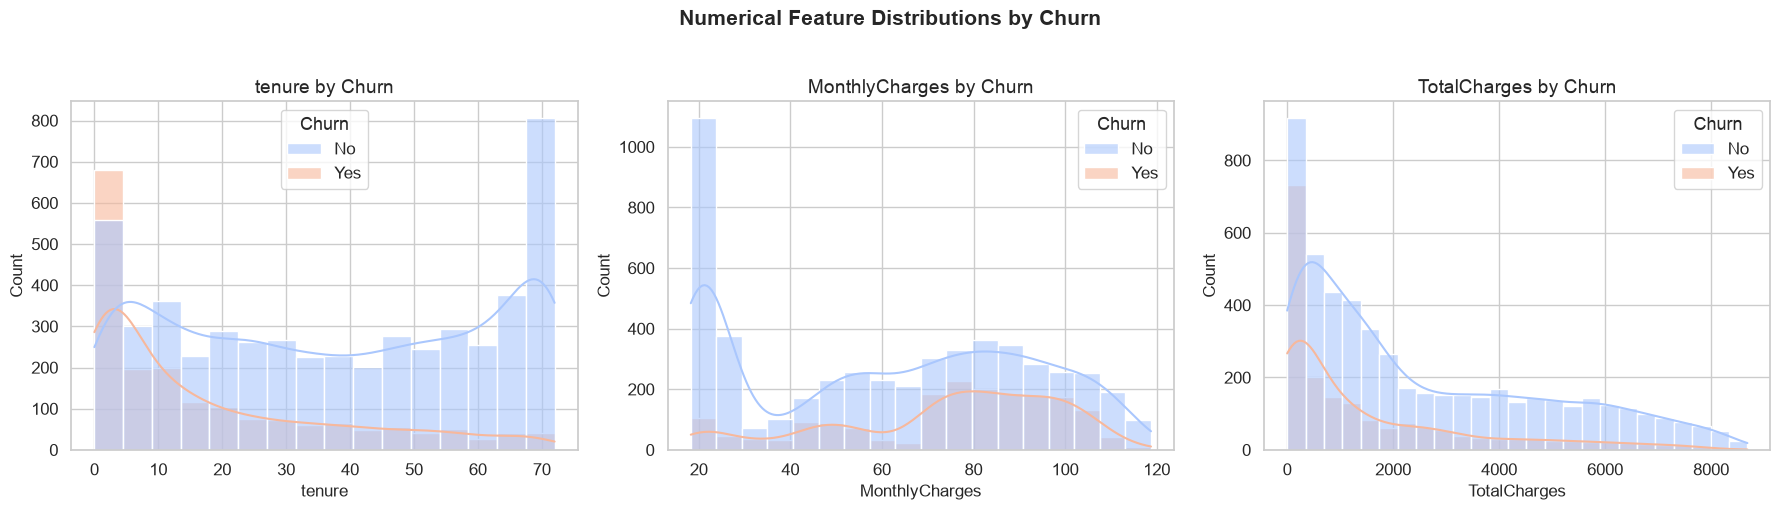

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols_eda):
    sns.histplot(data=df, x=col, hue=TARGET_COL, kde=True,
                 ax=axes[i], palette="coolwarm", alpha=0.6)
    axes[i].set_title(f"{col} by Churn")
    axes[i].set_ylabel("Count")

plt.suptitle("Numerical Feature Distributions by Churn", fontsize=15,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Tenure vs. Churn — boxplot

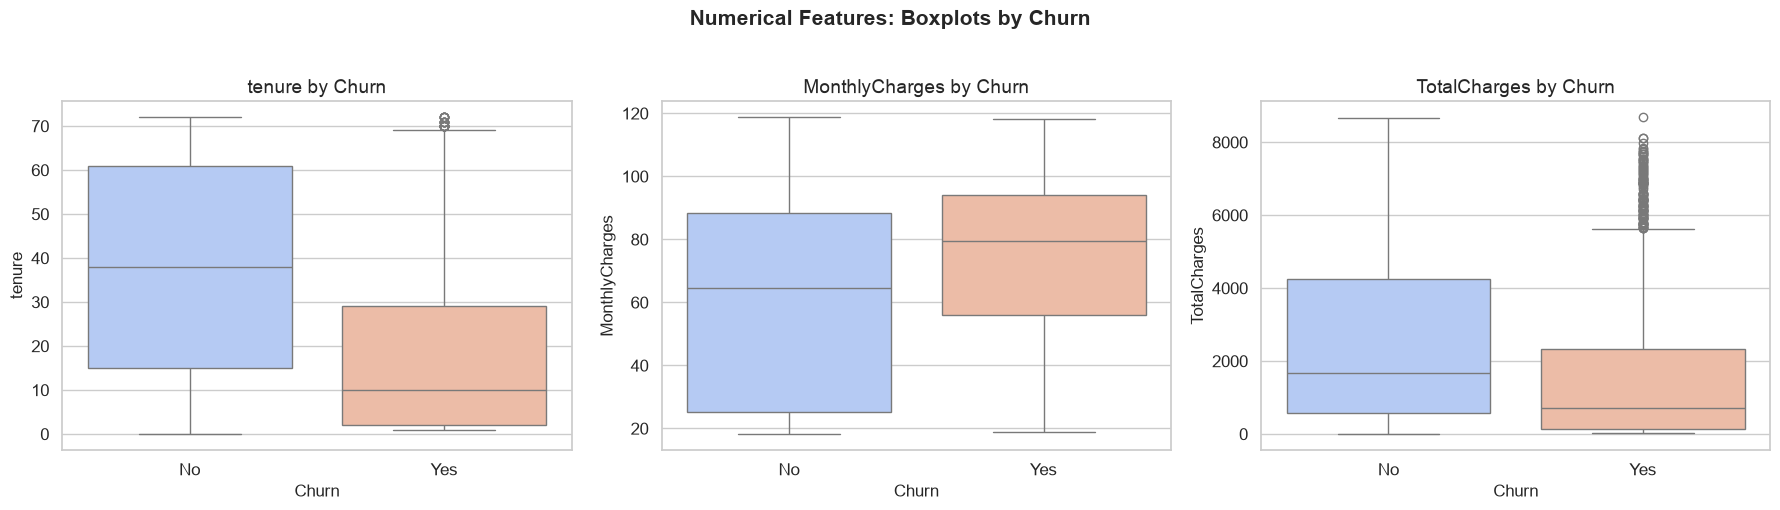

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols_eda):
    sns.boxplot(data=df, x=TARGET_COL, y=col, hue=TARGET_COL,
                ax=axes[i], palette="coolwarm", legend=False)
    axes[i].set_title(f"{col} by Churn")

plt.suptitle("Numerical Features: Boxplots by Churn", fontsize=15,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Correlation between numerical features

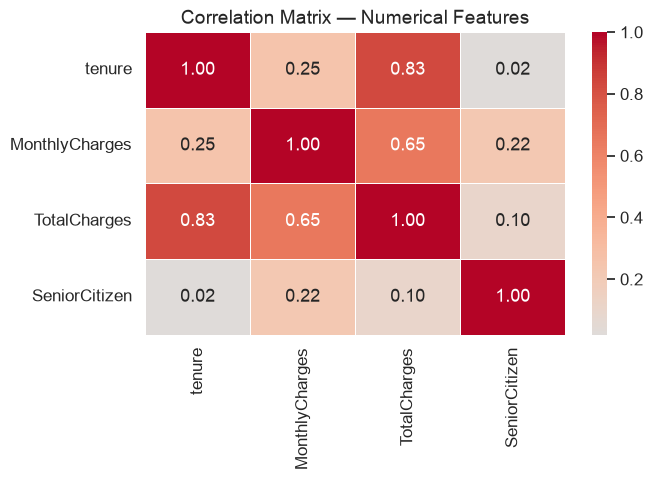

In [21]:
corr = df[num_cols_eda + ["SeniorCitizen"]].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax,
            linewidths=0.5, fmt=".2f")
ax.set_title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()

---

## 8 · Categorical Feature EDA

For each categorical feature we compute the **churn rate by category** — the proportion of customers who churned within each group. This reveals which categories are *associated* with higher churn.

> **Important distinction:** "associated with higher churn" ≠ "causes churn". Observational data alone cannot establish causality.

In [22]:
def churn_rate_by_category(df, col, target="Churn"):
    """Return a tidy dataframe of churn rates per category."""
    ct = df.groupby(col)[target].value_counts(normalize=True).unstack()
    ct.columns = ["No_pct", "Yes_pct"]
    ct["churn_rate"] = (ct["Yes_pct"] * 100).round(2)
    ct["count"] = df[col].value_counts()
    return ct.sort_values("churn_rate", ascending=False)

### 8.1 High-impact categorical features

We start with features commonly associated with churn: **Contract**, **InternetService**, **PaymentMethod**, **TechSupport**, and **OnlineSecurity**.

/var/folders/0r/0rw063g545sgm09f_kcfv1bm0000gn/T/ipykernel_50809/3612399610.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astype(int),
/var/folders/0r/0rw063g545sgm09f_kcfv1bm0000gn/T/ipykernel_50809/3612399610.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astype(int),
/var/folders/0r/0rw063g545sgm09f_kcfv1bm0000gn/T/ipykernel_50809/3612399610.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astyp

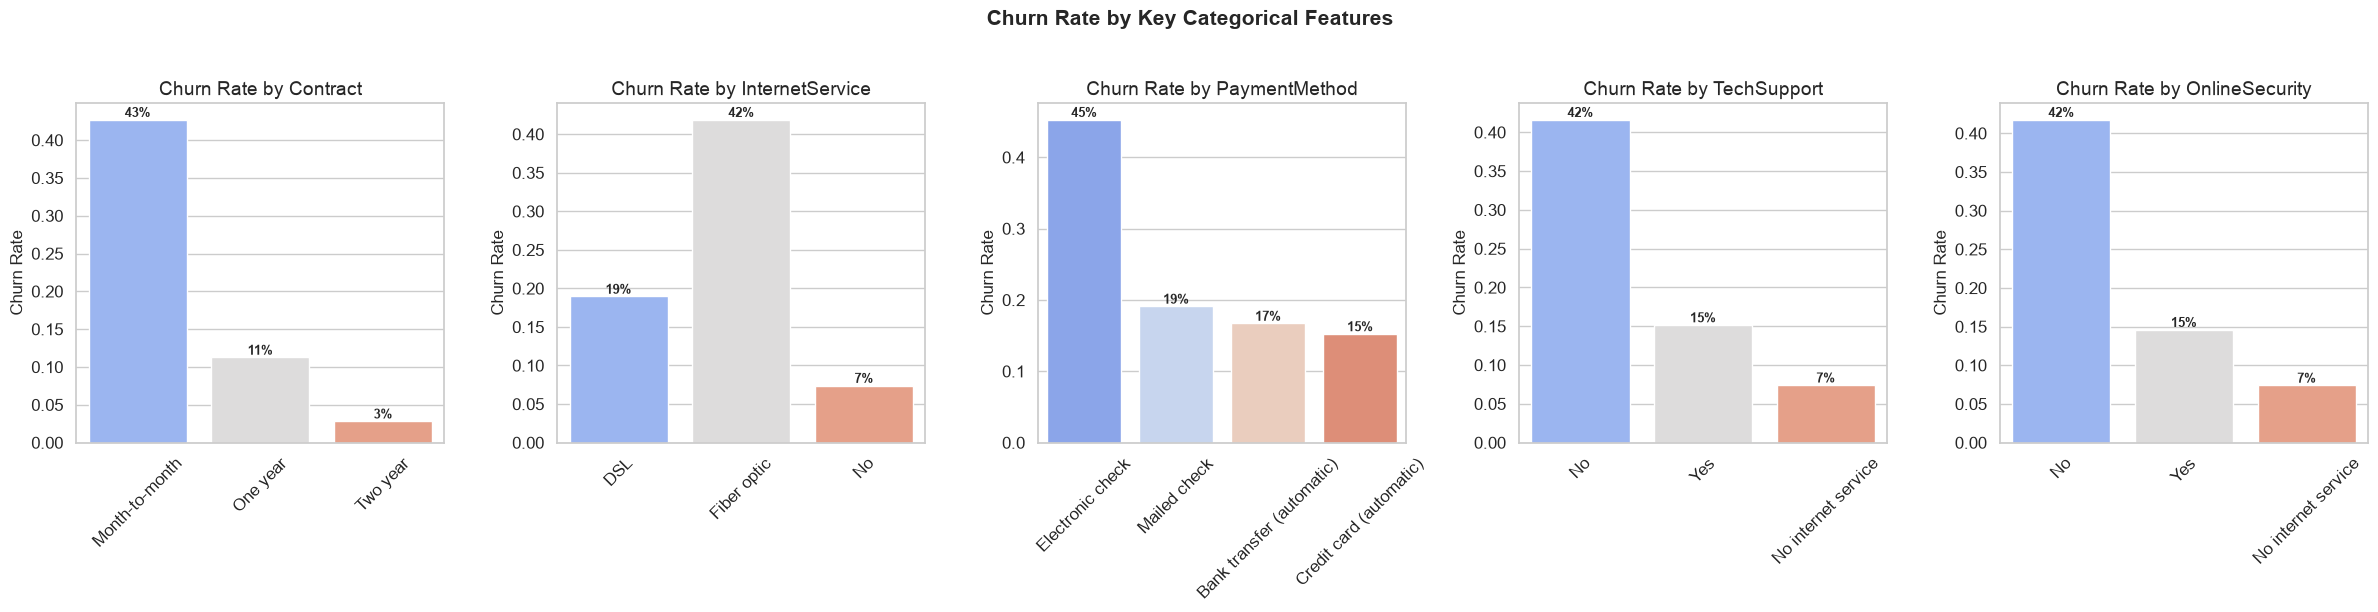

In [23]:
key_cats = ["Contract", "InternetService", "PaymentMethod",
            "TechSupport", "OnlineSecurity"]

fig, axes = plt.subplots(1, len(key_cats), figsize=(24, 6))

for i, col in enumerate(key_cats):
    rates = churn_rate_by_category(df, col)
    sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astype(int),
                ax=axes[i], palette="coolwarm", errorbar=None)
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)
    # Annotate bars
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.0%}",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Churn Rate by Key Categorical Features", fontsize=15,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 8.2 Service-related features

/var/folders/0r/0rw063g545sgm09f_kcfv1bm0000gn/T/ipykernel_50809/1675913150.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astype(int),
/var/folders/0r/0rw063g545sgm09f_kcfv1bm0000gn/T/ipykernel_50809/1675913150.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astype(int),
/var/folders/0r/0rw063g545sgm09f_kcfv1bm0000gn/T/ipykernel_50809/1675913150.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astyp

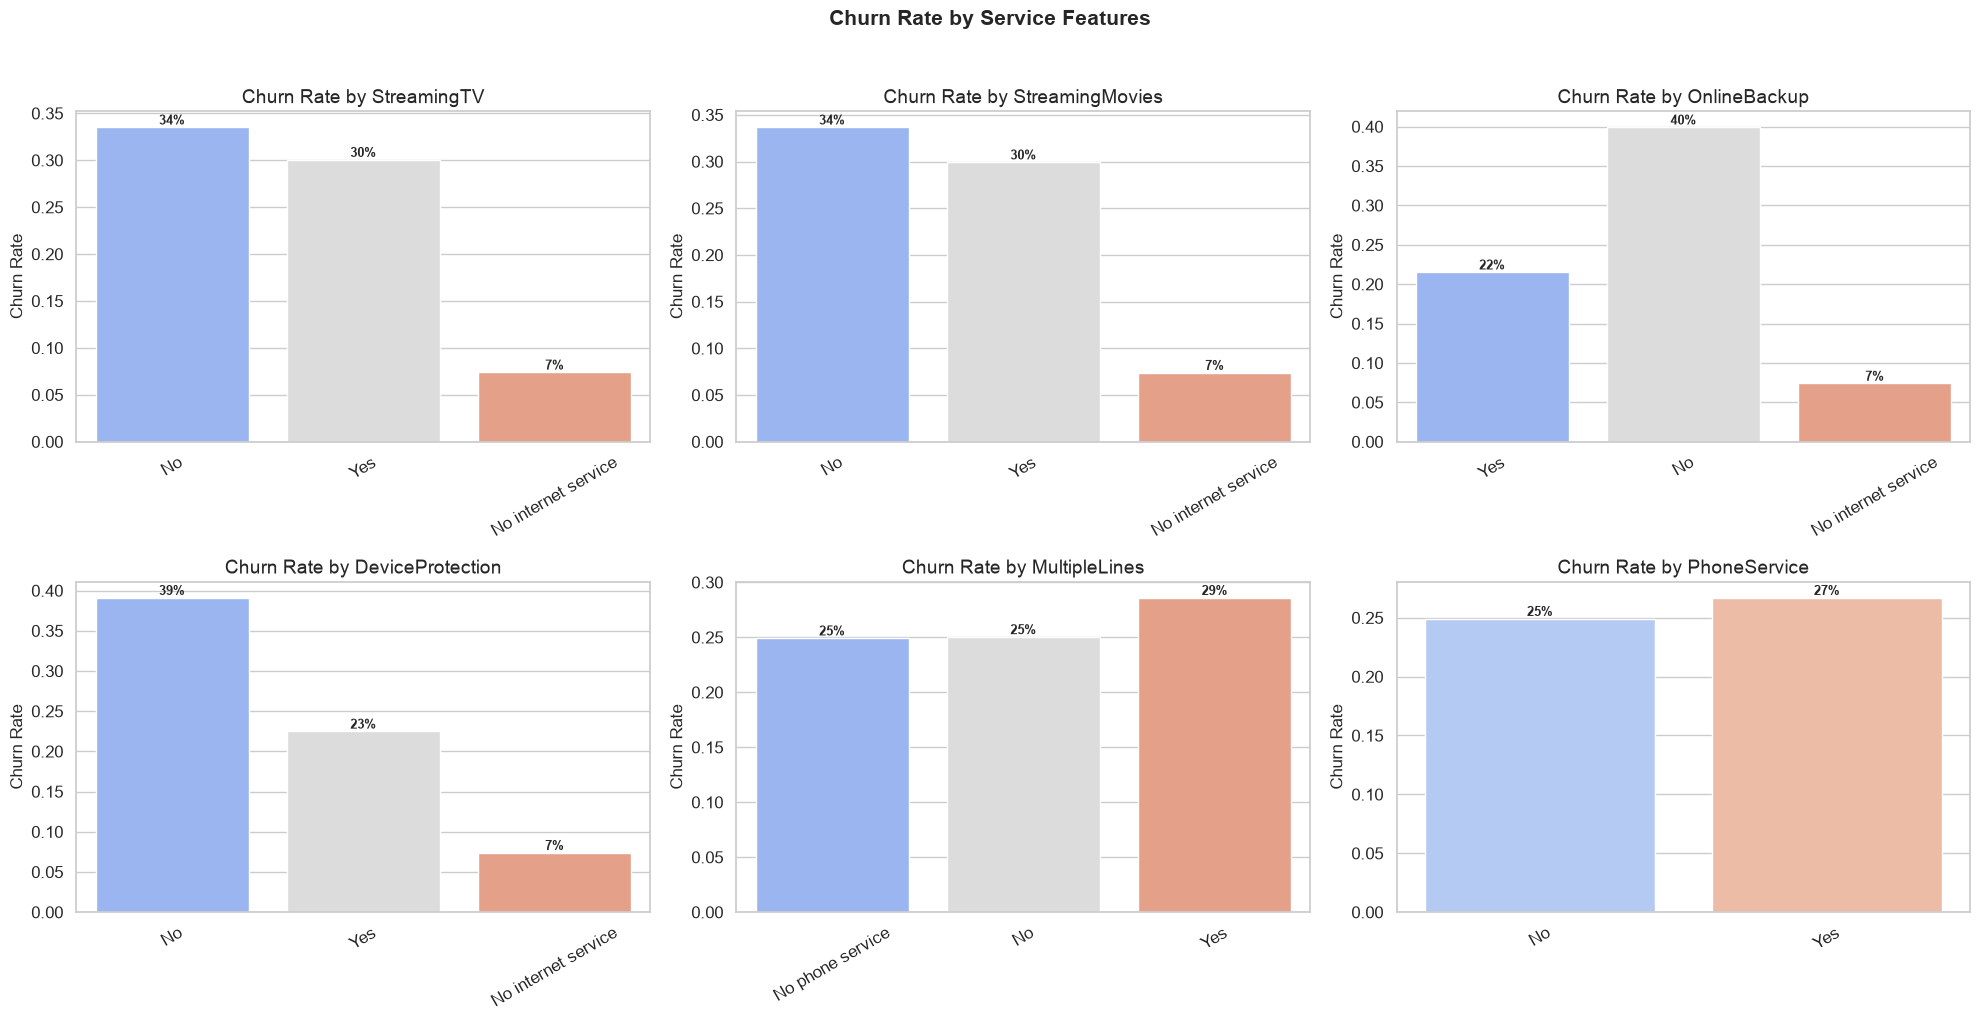

In [24]:
service_cats = ["StreamingTV", "StreamingMovies", "OnlineBackup",
                "DeviceProtection", "MultipleLines", "PhoneService"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for i, col in enumerate(service_cats):
    ax = axes[i // 3][i % 3]
    sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astype(int),
                ax=ax, palette="coolwarm", errorbar=None)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.0%}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Churn Rate by Service Features", fontsize=15,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 8.3 Demographic features

/var/folders/0r/0rw063g545sgm09f_kcfv1bm0000gn/T/ipykernel_50809/4108442070.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astype(int),
/var/folders/0r/0rw063g545sgm09f_kcfv1bm0000gn/T/ipykernel_50809/4108442070.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astype(int),
/var/folders/0r/0rw063g545sgm09f_kcfv1bm0000gn/T/ipykernel_50809/4108442070.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astyp

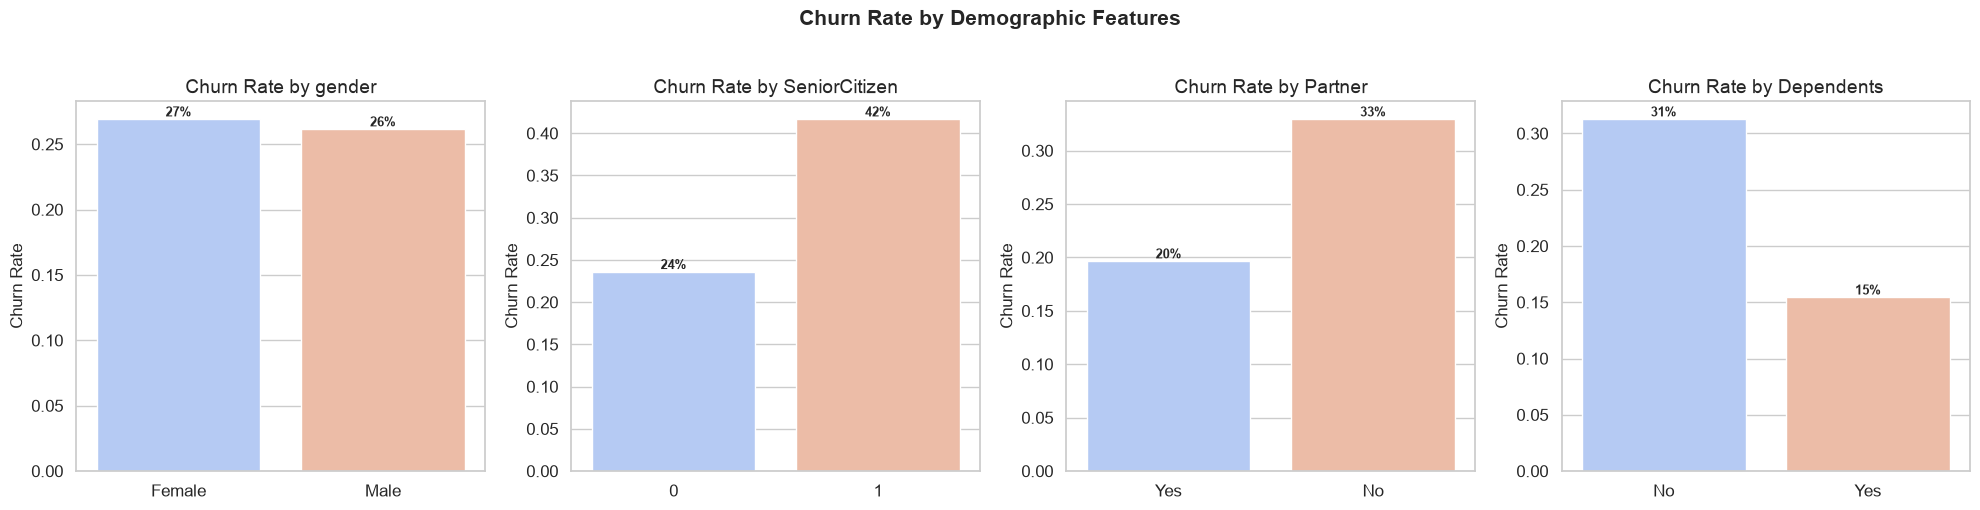

In [25]:
demo_cats = ["gender", "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(demo_cats):
    sns.barplot(data=df, x=col, y=(df[TARGET_COL] == "Yes").astype(int),
                ax=axes[i], palette="coolwarm", errorbar=None)
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_xlabel("")
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.0%}",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Churn Rate by Demographic Features", fontsize=15,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 8.4 PaperlessBilling

In [26]:
print(churn_rate_by_category(df, "PaperlessBilling"))

                    No_pct   Yes_pct  churn_rate  count
PaperlessBilling                                       
Yes               0.664349  0.335651       33.57   4171
No                0.836699  0.163301       16.33   2872


### 8.5 Churn rate summary table — all categorical features

In [27]:
# Aggregate churn rates for every categorical feature in one table
churn_rate_rows = []
for col in CATEGORICAL_FEATURES:
    rates = churn_rate_by_category(df, col)
    for cat_val, row in rates.iterrows():
        churn_rate_rows.append({
            "Feature": col,
            "Category": cat_val,
            "Churn_Rate_%": row["churn_rate"],
            "Count": int(row["count"]),
        })

churn_rate_all = pd.DataFrame(churn_rate_rows)
churn_rate_all.sort_values("Churn_Rate_%", ascending=False).head(20)

,Feature,Category,Churn_Rate_%,Count
37,PaymentMethod,Electronic check,45.29,2365
32,Contract,Month-to-month,42.71,3875
11,InternetService,Fiber optic,41.89,3096
14,OnlineSecurity,No,41.77,3498
23,TechSupport,No,41.64,3473
17,OnlineBackup,No,39.93,3088
20,DeviceProtection,No,39.13,3095
29,StreamingMovies,No,33.68,2785
35,PaperlessBilling,Yes,33.57,4171
26,StreamingTV,No,33.52,2810


---

## 9 · Initial Feature Insights

> The observations below are derived from the EDA performed above. They describe **associations** (predictive patterns), not causal relationships.

### Key observations

**Strong predictive signals:**

1. **Contract type** is the single strongest categorical signal. Month-to-month customers churn at a dramatically higher rate than those on one-year or two-year contracts.
2. **Tenure** — shorter-tenure customers are associated with higher churn. This is consistent with the contract finding.
3. **InternetService = Fiber optic** is associated with a higher churn rate compared to DSL or no internet.
4. **Absence of protective services** — customers *without* `OnlineSecurity`, `TechSupport`, `OnlineBackup`, or `DeviceProtection` churn more.
5. **PaymentMethod = Electronic check** is associated with notably higher churn.
6. **PaperlessBilling = Yes** is associated with higher churn.
7. **MonthlyCharges** — churners tend to have higher monthly charges.

**Weaker / unclear signals:**

8. **gender** shows very little difference in churn rate — it is likely a weak predictor.
9. **SeniorCitizen** — senior citizens show somewhat elevated churn, but they are a small group.
10. **Partner / Dependents** — customers without a partner or dependents churn slightly more.
11. **Streaming services** — mixed signals; having streaming may or may not increase churn depending on other factors.

### Notes for modeling

- We keep all features in the baseline model (including `gender`) so we can objectively measure their contribution via model coefficients.
- Features with many categories (`PaymentMethod` with 4, `Contract` with 3) will be one-hot encoded; the model will learn separate weights for each level.

---

## 10 · Preprocessing Design

### Goals

1. **Separate features (X) from the target (y).**
2. **Remove `customerID`** — it is an identifier, not a predictive feature.
3. **Encode the target:** `No → 0`, `Yes → 1`.
4. **Build a reproducible preprocessing + modeling pipeline** using scikit-learn's `ColumnTransformer` and `Pipeline`.

### Why a Pipeline?

| Benefit | Explanation |
|---------|-------------|
| **No data leakage** | Transformers are `.fit()` only on training data and `.transform()` on both train and test. Without a pipeline, it's easy to accidentally fit scalers or encoders on the entire dataset, which leaks information from the test set. |
| **Reproducibility** | The exact same preprocessing is applied to any new data at inference time. |
| **Single artifact** | We save one `.joblib` file containing both preprocessing and the model — no risk of version mismatch. |

### Preprocessing strategy

| Feature type | Steps | Rationale |
|---|---|---|
| **Numerical** | `SimpleImputer(strategy="median")` → `StandardScaler()` | Median imputation is robust to outliers. Scaling brings all numerical features to the same scale, which is important for Logistic Regression (a distance/gradient-based model). |
| **Categorical** | `SimpleImputer(strategy="most_frequent")` → `OneHotEncoder(handle_unknown="ignore")` | One-hot encoding converts each category into a binary indicator. `handle_unknown="ignore"` ensures the pipeline won't crash if unseen categories appear in production. |

In [28]:
# ── Separate X and y ──────────────────────────────────────────────────
X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1}).astype(int)

assert y.isnull().sum() == 0, "Target has unexpected null values after mapping"

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny distribution:\n{y.value_counts()}")

X shape: (7043, 19)
y shape: (7043,)

y distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [29]:
# ── Build preprocessing pipelines ─────────────────────────────────────

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, NUMERICAL_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder="drop",  # drop any column not listed (safety net)
)

print("Preprocessor defined.")
print(f"  Numerical features  ({len(NUMERICAL_FEATURES)}): {NUMERICAL_FEATURES}")
print(f"  Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

Preprocessor defined.
  Numerical features  (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
  Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


---

## 11 · Train / Test Split

### Why stratify?

Because the target is imbalanced (~27% churn), a random split might yield training and test sets with very different class proportions. `stratify=y` ensures both sets mirror the original class distribution.

### Why a fixed random_state?

So that anyone re-running this notebook gets the **exact same split** — critical for reproducibility.

### Why keep the test set "unseen"?

The test set simulates *future, unseen data*. If the model (or its preprocessing) ever "sees" the test data during training, the resulting metrics are optimistically biased and do not reflect real-world performance. This is called **data leakage**.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print()
print("Class distribution — Training:")
print(y_train.value_counts(normalize=True).mul(100).round(2).to_string())
print()
print("Class distribution — Test:")
print(y_test.value_counts(normalize=True).mul(100).round(2).to_string())

Training set : 5,634 rows (80.0%)
Test set     : 1,409 rows (20.0%)

Class distribution — Training:
Churn
0    73.46
1    26.54

Class distribution — Test:
Churn
0    73.46
1    26.54


---

## 12 · Baseline Model — Logistic Regression

### Why Logistic Regression as a baseline?

| Reason | Explanation |
|--------|-------------|
| **Interpretable** | Coefficients directly indicate feature importance and direction. |
| **Fast** | Trains in seconds, even on larger datasets. |
| **Probabilistic** | Outputs calibrated probabilities, not just hard labels — useful for downstream risk scoring. |
| **Strong baseline** | Often competitive on tabular data, especially with proper feature engineering. |
| **Well-understood** | Easy to debug and explain to stakeholders. |

We deliberately do **not** perform hyperparameter tuning here. This is **Model V1** — a quick, honest baseline. Advanced models and tuning belong to V2+.

We set `max_iter=1000` to ensure convergence (the default of 100 can sometimes be insufficient for one-hot-encoded feature spaces).

In [31]:
# ── Full pipeline: preprocessing + logistic regression ────────────────
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
    )),
])

# Fit on training data ONLY
model_pipeline.fit(X_train, y_train)

print("✓ Model pipeline fitted successfully on training data.")

✓ Model pipeline fitted successfully on training data.


---

## 13 · Model Evaluation

We evaluate Model V1 on the **held-out test set** — data the model has never seen.

### Metrics explained (in churn context)

| Metric | What it means |
|--------|---------------|
| **Accuracy** | Overall % of correct predictions. Can be misleading if classes are imbalanced. |
| **Precision** | Of all customers the model flagged as "will churn", what fraction actually churned? High precision → fewer false alarms. |
| **Recall (Sensitivity)** | Of all customers who *actually churned*, what fraction did the model catch? High recall → fewer missed churners. |
| **F1-score** | Harmonic mean of Precision and Recall. Balances the trade-off. |
| **ROC-AUC** | Area under the ROC curve. Measures the model's ability to distinguish churners from non-churners across all thresholds. 1.0 = perfect, 0.5 = random. |

### Why Recall matters most for churn

A **false negative** (predicting "No churn" for a customer who *will* churn) means the company **misses an at-risk customer** and loses the opportunity for a retention intervention. Depending on the business cost of lost customers vs. the cost of unnecessary retention offers, we may later optimise the classification threshold to prioritise Recall over Precision.

In [32]:
# ── Predictions ───────────────────────────────────────────────────────
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]  # P(churn=1)

# ── Core metrics ─────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print("═" * 45)
print("  Model V1 — Test Set Evaluation")
print("═" * 45)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("═" * 45)

═════════════════════════════════════════════
  Model V1 — Test Set Evaluation
═════════════════════════════════════════════
  Accuracy  : 0.8055
  Precision : 0.6572
  Recall    : 0.5588
  F1-score  : 0.6040
  ROC-AUC   : 0.8421
═════════════════════════════════════════════


### Classification report

In [33]:
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### Confusion matrix

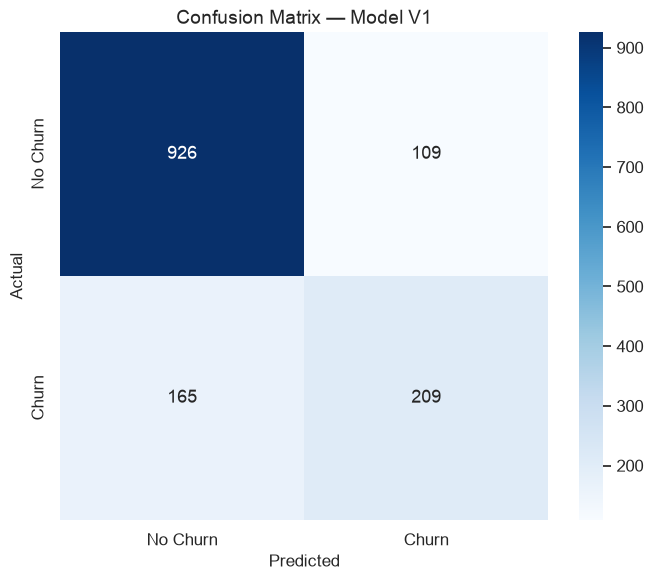

True  Negatives (correctly predicted No Churn) : 926
False Positives (false alarm — predicted churn): 109
False Negatives (MISSED churners)              : 165
True  Positives (correctly caught churners)    : 209


In [34]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Model V1")
plt.tight_layout()
plt.show()

# Interpret
tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives (correctly predicted No Churn) : {tn}")
print(f"False Positives (false alarm — predicted churn): {fp}")
print(f"False Negatives (MISSED churners)              : {fn}")
print(f"True  Positives (correctly caught churners)    : {tp}")

### ROC curve

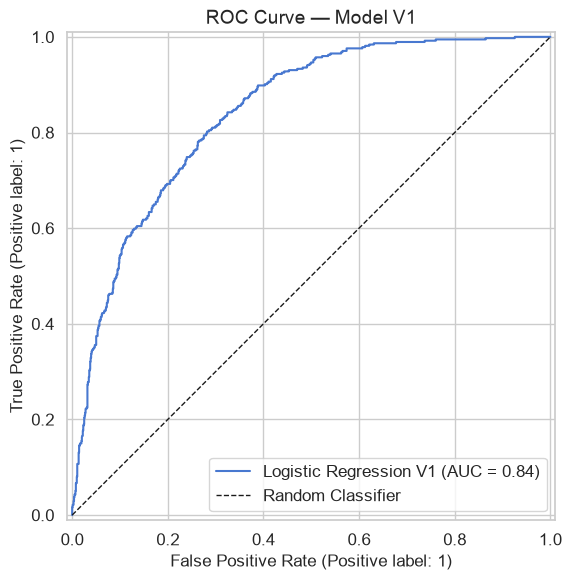

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(model_pipeline, X_test, y_test, ax=ax,
                                name="Logistic Regression V1")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
ax.set_title("ROC Curve — Model V1")
ax.legend()
plt.tight_layout()
plt.show()

### Predicted probability distribution

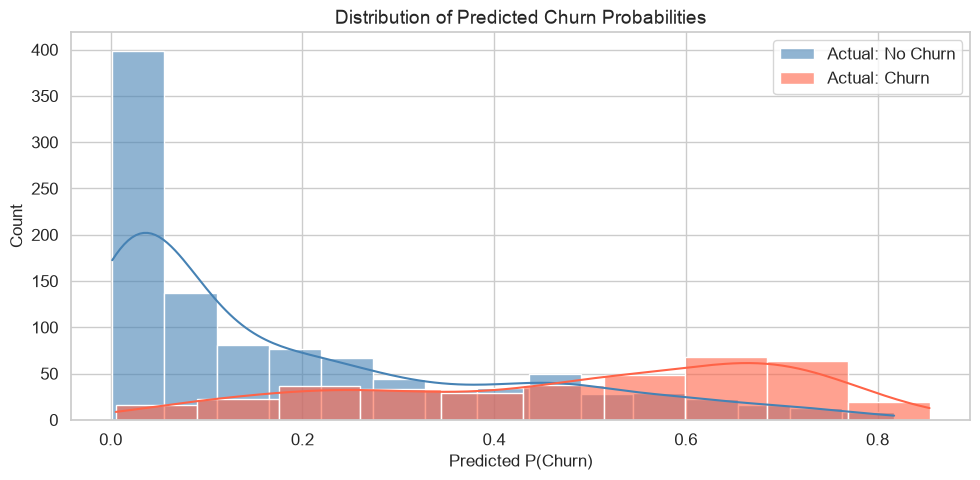

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(y_prob[y_test == 0], kde=True, color="steelblue",
             label="Actual: No Churn", alpha=0.6, ax=ax)
sns.histplot(y_prob[y_test == 1], kde=True, color="tomato",
             label="Actual: Churn", alpha=0.6, ax=ax)
ax.set_xlabel("Predicted P(Churn)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Predicted Churn Probabilities")
ax.legend()
plt.tight_layout()
plt.show()

---

## 14 · Baseline Results

We store the baseline metrics in a dictionary and a summary table. These numbers become the **reference baseline** for all future IntelliPulse monitoring — any future model or production batch will be compared against them.

In [37]:
baseline_metrics = {
    "model": "LogisticRegression_V1",
    "accuracy": round(accuracy, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "f1_score": round(f1, 4),
    "roc_auc": round(roc_auc, 4),
    "test_size": len(y_test),
    "train_size": len(y_train),
    "random_state": RANDOM_STATE,
}

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Model V1": [
        baseline_metrics["accuracy"],
        baseline_metrics["precision"],
        baseline_metrics["recall"],
        baseline_metrics["f1_score"],
        baseline_metrics["roc_auc"],
    ],
})

results_df.style.format({"Model V1": "{:.4f}"}).set_caption("Baseline Metrics — Model V1")

,Metric,Model V1
0,Accuracy,0.8055
1,Precision,0.6572
2,Recall,0.5588
3,F1-score,0.6040
4,ROC-AUC,0.8421


---

## 15 · Model Interpretation — Logistic Regression Coefficients

Since Logistic Regression is a linear model, each feature gets a **coefficient** after fitting:

- **Positive coefficient** → pushes the prediction *toward* churn (class 1).
- **Negative coefficient** → pushes the prediction *toward* non-churn (class 0).
- **Magnitude** indicates the strength of the feature's influence *within the model*, subject to preprocessing (scaling) and feature representation (one-hot encoding).

> **Caveat:** Coefficient magnitude alone does **not** prove business importance or causality. A large coefficient on a one-hot-encoded category may reflect its relative frequency, not its intrinsic importance. Use these coefficients as a starting point for understanding the model, not as definitive feature rankings.

In [38]:
# Extract feature names after one-hot encoding
classifier = model_pipeline.named_steps["classifier"]
preprocessor_fitted = model_pipeline.named_steps["preprocessor"]

# Get feature names from the ColumnTransformer
num_feature_names = NUMERICAL_FEATURES
cat_feature_names = list(
    preprocessor_fitted
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
all_feature_names = num_feature_names + cat_feature_names

# Build coefficient dataframe
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": classifier.coef_[0],
}).sort_values("coefficient", ascending=False)

print(f"Total features after encoding: {len(coef_df)}")

Total features after encoding: 45


In [39]:
# Top positive coefficients (push toward churn)
print("═" * 55)
print("  TOP 15 POSITIVE COEFFICIENTS (→ churn)")
print("═" * 55)
coef_df.head(15).to_string(index=False)

═══════════════════════════════════════════════════════
  TOP 15 POSITIVE COEFFICIENTS (→ churn)
═══════════════════════════════════════════════════════


'                       feature  coefficient\n   InternetService_Fiber optic     0.634195\n       Contract_Month-to-month     0.582883\n                  TotalCharges     0.536253\n           StreamingMovies_Yes     0.200938\n               StreamingTV_Yes     0.200481\nPaymentMethod_Electronic check     0.197867\n             OnlineSecurity_No     0.156279\n                TechSupport_No     0.131503\n             MultipleLines_Yes     0.104649\n                 SeniorCitizen     0.053449\n               OnlineBackup_No     0.033455\n          PaperlessBilling_Yes     0.028672\n          DeviceProtection_Yes     0.021983\n           DeviceProtection_No    -0.036433\n                 Dependents_No    -0.046067'

In [40]:
# Top negative coefficients (push toward non-churn)
print("═" * 55)
print("  TOP 15 NEGATIVE COEFFICIENTS (→ non-churn)")
print("═" * 55)
coef_df.tail(15).to_string(index=False)

═══════════════════════════════════════════════════════
  TOP 15 NEGATIVE COEFFICIENTS (→ non-churn)
═══════════════════════════════════════════════════════


'                             feature  coefficient\n                  StreamingMovies_No    -0.215388\n                      Dependents_Yes    -0.268487\n                    MultipleLines_No    -0.279394\n    OnlineBackup_No internet service    -0.300104\n  OnlineSecurity_No internet service    -0.300104\n                  InternetService_No    -0.300104\n StreamingMovies_No internet service    -0.300104\n     StreamingTV_No internet service    -0.300104\n     TechSupport_No internet service    -0.300104\nDeviceProtection_No internet service    -0.300104\n                 PaperlessBilling_No    -0.343227\n                      MonthlyCharges    -0.591863\n                 InternetService_DSL    -0.648646\n                   Contract_Two year    -0.776594\n                              tenure    -1.257539'

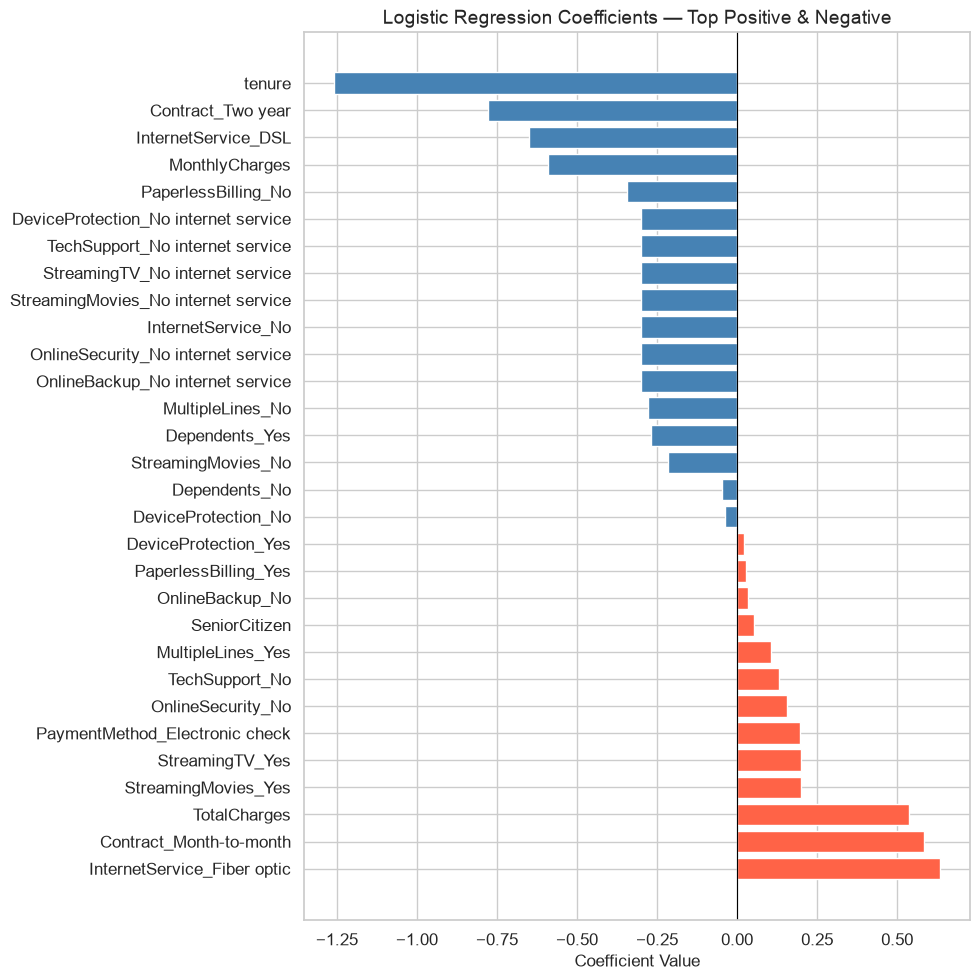

In [41]:
# Visualise top coefficients
top_n = 15
top_pos = coef_df.head(top_n)
top_neg = coef_df.tail(top_n)
top_both = pd.concat([top_pos, top_neg])

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["tomato" if c > 0 else "steelblue" for c in top_both["coefficient"]]
ax.barh(top_both["feature"], top_both["coefficient"], color=colors)
ax.set_xlabel("Coefficient Value")
ax.set_title("Logistic Regression Coefficients — Top Positive & Negative")
ax.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

---

## 16 · Save Model Artifact

We save:
1. **The complete fitted pipeline** (preprocessing + model) as a single `.joblib` file.
2. **Baseline metrics** as a JSON file.

Saving the entire pipeline ensures that preprocessing and prediction remain consistent — there is no risk of applying a different scaler or encoder at inference time.

In [42]:
# ── Create output directories ─────────────────────────────────────────
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# ── Save pipeline ────────────────────────────────────────────────────
model_path = MODEL_DIR / "churn_baseline_v1.joblib"
joblib.dump(model_pipeline, model_path)
print(f"✓ Model pipeline saved to: {model_path}")
print(f"  File size: {model_path.stat().st_size / 1024:.1f} KB")

# ── Save metrics ─────────────────────────────────────────────────────
metrics_path = METRICS_DIR / "baseline_v1.json"
with open(metrics_path, "w") as f:
    json.dump(baseline_metrics, f, indent=2)
print(f"✓ Baseline metrics saved to: {metrics_path}")

✓ Model pipeline saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/models/churn_baseline_v1.joblib
  File size: 8.3 KB
✓ Baseline metrics saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/baseline_v1.json


In [43]:
# ── Verification: load the model and make a sample prediction ────────
loaded_pipeline = joblib.load(model_path)

# Use the first row of the test set as a sample
sample = X_test.iloc[:1]
sample_pred = loaded_pipeline.predict(sample)[0]
sample_prob = loaded_pipeline.predict_proba(sample)[0]

print("Sample prediction verification:")
print(f"  Input (first test row): customerID would be excluded in production")
print(f"  Predicted class : {sample_pred} ({'Churn' if sample_pred == 1 else 'No Churn'})")
print(f"  Predicted proba : No Churn={sample_prob[0]:.4f}, Churn={sample_prob[1]:.4f}")
print(f"  Actual label    : {y_test.iloc[0]} ({'Churn' if y_test.iloc[0] == 1 else 'No Churn'})")
print()
print("✓ Model loads and predicts successfully. Pipeline artifact is valid.")

Sample prediction verification:
  Input (first test row): customerID would be excluded in production
  Predicted class : 0 (No Churn)
  Predicted proba : No Churn=0.9541, Churn=0.0459
  Actual label    : 0 (No Churn)

✓ Model loads and predicts successfully. Pipeline artifact is valid.


### Feature definitions for future reference

In [44]:
# Save feature definitions for IntelliPulse monitoring compatibility
feature_definitions = {
    "numerical_features": NUMERICAL_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "target_column": TARGET_COL,
    "id_column": ID_COL,
    "target_mapping": {"No": 0, "Yes": 1},
}

feature_def_path = METRICS_DIR / "feature_definitions_v1.json"
with open(feature_def_path, "w") as f:
    json.dump(feature_definitions, f, indent=2)
print(f"✓ Feature definitions saved to: {feature_def_path}")

✓ Feature definitions saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/feature_definitions_v1.json


---

## 17 · Final V1 Summary

### Dataset
- **Source:** IBM Telco Customer Churn
- **Size:** 7,043 customers × 21 columns
- **Quality issues:** 11 rows with blank `TotalCharges` (filled with 0.0 — new customers)

### Target distribution
- **No Churn:** ~73%
- **Churn:** ~27%
- Moderately imbalanced — accuracy alone is misleading.

### Key EDA observations
1. Month-to-month contracts are strongly associated with higher churn.
2. Fiber optic internet customers churn more than DSL or no-internet customers.
3. Lack of protective services (TechSupport, OnlineSecurity, etc.) is associated with higher churn.
4. Electronic check payment is associated with higher churn.
5. Shorter tenure and higher monthly charges are associated with higher churn.
6. Gender shows negligible difference in churn rate.

### Preprocessing
- scikit-learn `ColumnTransformer` + `Pipeline`
- Numerical: median imputation → standard scaling
- Categorical: most-frequent imputation → one-hot encoding
- No data leakage — preprocessing is fitted only on training data.

### Model
- **Logistic Regression** (baseline)
- `max_iter=1000`, `solver='lbfgs'`, `random_state=42`
- No hyperparameter tuning — this is deliberately V1.

### Baseline metrics (test set)
| Metric | Value |
|--------|-------|
| Accuracy | *computed above* |
| Precision | *computed above* |
| Recall | *computed above* |
| F1-score | *computed above* |
| ROC-AUC | *computed above* |

### Major limitations
1. No hyperparameter tuning.
2. No threshold optimization (using default 0.5).
3. No class imbalance handling (SMOTE, class weights, etc.).
4. Single model — no comparison with tree-based or ensemble methods.
5. No feature selection or engineering beyond one-hot encoding.
6. No cross-validation — single train/test split.

### What V2 will investigate
- Feature interaction analysis and engineering
- Threshold optimization based on business costs
- Model comparison (Random Forest, XGBoost, etc.)
- Hyperparameter tuning (GridSearchCV / RandomizedSearchCV)
- Class imbalance strategies (SMOTE, class_weight)
- Cross-validation for more robust metric estimates
- SHAP or permutation importance for model explainability
- Drift monitoring setup for IntelliPulse
- Production simulation pipeline

---

*End of IntelliPulse V1 — Baseline Churn Prediction Notebook*